Selected graph: Qmbkk9K2UKpP5epZyxgoLcEh5gm1MjWBJ2vux28xfPuaWB.pt


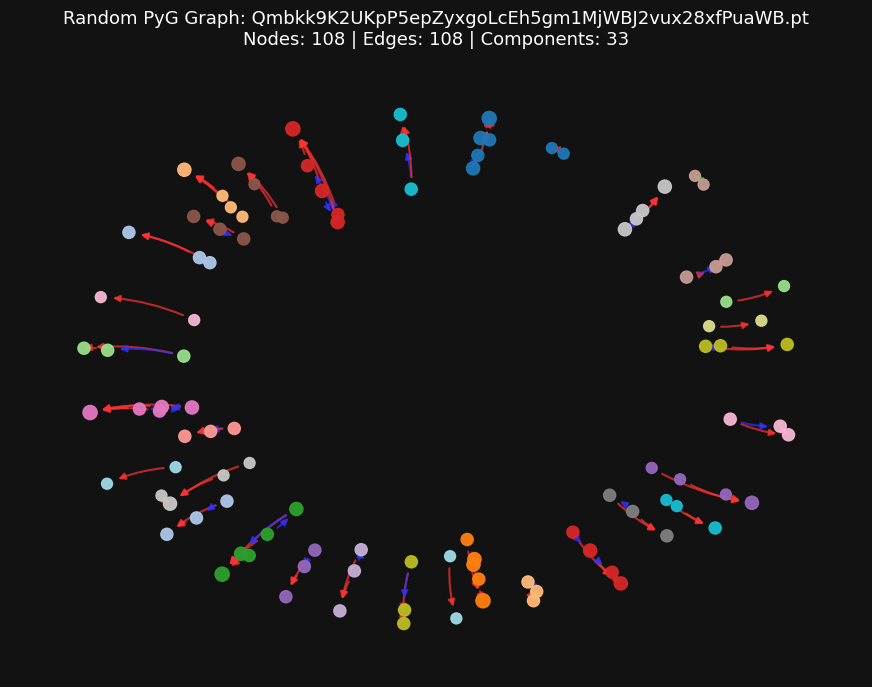

In [20]:
# Standard library imports
import random
from pathlib import Path

# Third party imports
import torch
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

EDGE_CLASSES = {
    1: "Class 1: Structural",
    2: "Class 2: Modifier",
    3: "Class 3: Temporal",
    4: "Class 4: Sync",
}
EDGE_COLORS = {
    1: "#ff3333",
    2: "#33cc33",
    3: "#3333ff",
    4: "#ff9900",
}
DEFAULT_EDGE_COLOR = "#9aa0a6"

possible_dirs = [
    Path("data/validation-small/graphs"),
    Path("../data/validation-small/graphs"),
    Path("../../data/validation-small/graphs"),
]
graph_dir = next((p.resolve() for p in possible_dirs if p.exists()), None)
if graph_dir is None:
    raise FileNotFoundError(
        "Could not find data/validation-small/graphs from current working directory."
    )

pt_files = sorted(graph_dir.glob("*.pt"))
if not pt_files:
    raise FileNotFoundError(f"No .pt files found in {graph_dir}")

chosen = random.choice(pt_files)
print(f"Selected graph: {chosen.name}")

data = torch.load(chosen, map_location="cpu", weights_only=False)
if isinstance(data, dict) and "edge_index" in data:
    edge_index = data["edge_index"]
    pos = data.get("pos", None)
    x = data.get("x", None)
    y = data.get("y", None)
    explicit_num_nodes = data.get("num_nodes", None)
else:
    edge_index = data.edge_index
    pos = getattr(data, "pos", None)
    x = getattr(data, "x", None)
    y = getattr(data, "y", None)
    explicit_num_nodes = getattr(data, "num_nodes", None)

if edge_index is None:
    raise ValueError("Loaded graph has no edge_index.")
if not torch.is_tensor(edge_index):
    edge_index = torch.as_tensor(edge_index)

if explicit_num_nodes is not None:
    num_nodes = int(explicit_num_nodes)
elif pos is not None and hasattr(pos, "shape") and len(pos.shape) >= 1:
    num_nodes = int(pos.shape[0])
elif x is not None and hasattr(x, "shape") and len(x.shape) >= 1:
    num_nodes = int(x.shape[0])
elif edge_index.numel() == 0:
    num_nodes = 0
else:
    num_nodes = int(edge_index.max(dim=1).values.max().item()) + 1

G = nx.DiGraph()
G.add_nodes_from(range(num_nodes))

edges = edge_index.t().tolist() if edge_index.numel() > 0 else []
if edges:
    G.add_edges_from(edges)

edge_types = None
if y is not None:
    y_tensor = y.detach().cpu() if hasattr(y, "detach") else y
    y_tensor = torch.as_tensor(y_tensor)
    if y_tensor.ndim >= 1 and len(edges) == int(y_tensor.shape[0]):
        edge_types = y_tensor.tolist()

# Minimal positioning: use graph pos if available, otherwise basic spring layout.
if pos is not None:
    pos_tensor = pos.detach().cpu() if hasattr(pos, "detach") else pos
    pos_tensor = torch.as_tensor(pos_tensor)
    if pos_tensor.ndim >= 2 and pos_tensor.shape[1] >= 2:
        draw_pos = {
            i: (float(pos_tensor[i, 0]), float(pos_tensor[i, 1]))
            for i in range(min(num_nodes, int(pos_tensor.shape[0])))
        }
        for i in range(num_nodes):
            draw_pos.setdefault(i, (0.0, 0.0))
    else:
        draw_pos = nx.spring_layout(G, seed=42)
else:
    draw_pos = nx.spring_layout(G, seed=42)

components = list(nx.weakly_connected_components(G)) if num_nodes > 0 else []
component_map = {}
for component_index, nodes in enumerate(components):
    for node in nodes:
        component_map[node] = component_index

num_components = max(1, len(components))
palette = plt.get_cmap("tab20", num_components)

if num_nodes > 0:
    node_colors = [palette(component_map.get(n, 0)) for n in G.nodes]
    degrees = dict(G.degree())
    node_sizes = [max(42, 48 + 14 * degrees.get(n, 0)) for n in G.nodes]
else:
    node_colors = []
    node_sizes = []

if edge_types is not None:
    edge_colors = [EDGE_COLORS.get(int(t), DEFAULT_EDGE_COLOR) for t in edge_types]
else:
    edge_colors = [DEFAULT_EDGE_COLOR] * len(edges)

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("#121212")
ax.set_facecolor("#121212")

if num_nodes == 0:
    ax.text(
        0.5,
        0.5,
        "Empty graph (0 nodes)",
        color="white",
        ha="center",
        va="center",
        fontsize=14,
    )
    ax.axis("off")
else:
    nx.draw_networkx_nodes(
        G,
        draw_pos,
        nodelist=list(G.nodes),
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.95,
        ax=ax,
    )

    edge_draw_kwargs = {
        "edgelist": edges,
        "edge_color": edge_colors,
        "width": 1.5,
        "alpha": 0.7,
        "ax": ax,
    }
    if num_nodes <= 180:
        edge_draw_kwargs.update(
            {
                "arrows": True,
                "arrowstyle": "-|>",
                "arrowsize": 10,
                "connectionstyle": "arc3,rad=0.1",
            }
        )
    else:
        edge_draw_kwargs["arrows"] = False

    nx.draw_networkx_edges(G, draw_pos, **edge_draw_kwargs)

    if num_nodes <= 35:
        nx.draw_networkx_labels(
            G,
            draw_pos,
            labels={n: str(n) for n in G.nodes},
            font_size=8,
            font_color="white",
            ax=ax,
        )

"""     legend_handles = []
    for component_index in range(len(components)):
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="none",
                markerfacecolor=palette(component_index),
                markersize=8,
                label=f"Component {component_index + 1} ({len(components[component_index])} nodes)",
            )
        )
    if legend_handles:
        ax.legend(
            handles=legend_handles,
            loc="upper right",
            frameon=True,
            facecolor="#1e1e1e",
            edgecolor="#444",
            labelcolor="white",
        )
 """
ax.set_title(
    f"Random PyG Graph: {chosen.name}\nNodes: {num_nodes} | Edges: {len(edges)} | Components: {len(components)}",
    color="white",
    fontsize=13,
    pad=12,
)
ax.axis("off")
plt.show()